<a href="https://colab.research.google.com/github/epmbanten/Tugas-AI-602225073-Dody-Suhendra/blob/main/AHS_Classification_Custom_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Klasifikasi Ekspresi Wajah
**Penulis :** Djoko Purwanto (djoko@its.ac.id)<br>
**Deskripsi :** Program ini dirancang untuk melatih model untuk klasifikasi ekspresi wajah dalam kondisi marah, bahagia, atau sedih. Model dibuat dan dilatih menggunakan dataset ekspresi wajah.<br>

In [24]:
student_name = 'Dody_Suhendra'       # Write your name here
student_id = '6022251073'
print(f'Hello, {student_name} ({student_id}) !')

Hello, Dody_Suhendra (6022251073) !


### Inisialisasi
Set `RUN_COLAB` menjadi `True` bila program dijalankan di Google Colab

In [25]:
import os
from zipfile import ZipFile

RUN_COLAB = True

def upload_and_unzip_data(run_on_colab, data_file_name):
    """
    This function uploads and unzips a data file if running on Google Colab.
    If not running on Google Colab, it simply prints a message.
    """
    print('Program start ...')

    if run_on_colab:
        from google.colab import files

        print('Program runs on Google Colab')

        if data_file_name not in os.listdir():
            print(f'Uploading {data_file_name}...')
            files.upload()  # upload .zip file

        print(f'Unzipping {data_file_name}...')
        with ZipFile(data_file_name, 'r') as zip_ref:
            zip_ref.extractall()

        print('Data uploaded and unzipped')
    else:
        print('Program runs on local computer')


# Call the function with the run_on_colab flag and data file name
upload_and_unzip_data(RUN_COLAB, 'AHS_data.zip')

Program start ...
Program runs on Google Colab
Unzipping AHS_data.zip...
Data uploaded and unzipped


Cek versi TensorFlow dan GPU

In [26]:
import sys
import platform
import psutil
import tensorflow as tf
from datetime import datetime

def get_system_info():
    info = {}
    # Get system information
    info['platform'] = platform.system()
    info['architecture'] = platform.machine()
    info['hostname'] = platform.node()
    info['processor'] = platform.processor()
    info['ram'] = str(round(psutil.virtual_memory().total / (1024.0 **3))) + ' GB'
    return info

def check_tf_gpu():
    print(f'TensorFlow version is: {tf.__version__}')
    if tf.config.list_physical_devices('GPU'):
        print('GPU is being used by TensorFlow')
    else:
        print('GPU is unavailable for TensorFlow')

# Print the system information
system_info = get_system_info()
for key, value in system_info.items():
    print(f'{key}: {value}')

# Get the Python version
version = sys.version
print(f'The current Python version is: {version}')

check_tf_gpu()

# Get the current time
current_time = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
# Print the current time
print(f'The current time is: {current_time}')

platform: Linux
architecture: x86_64
hostname: c57f163ace39
processor: x86_64
ram: 13 GB
The current Python version is: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TensorFlow version is: 2.20.0
GPU is being used by TensorFlow
The current time is: 2026-05-23 08:22:25


### Dataset
Data disimpan dalam directory `AHS_data` yang terdiri dari subdirectory ekspresi wajah (`Angry`,`Happy`, `Sad`). Nama subdirectory digunakan sebagai nama kelas, dan di dalam subdirectory terdapat file-file gambar sesuai dengan kelas.

In [27]:
DIRECTORY_NAME = 'AHS_data'

def get_class_names(dir_name):
    """
    This function returns the names of all subdirectories in the specified directory.
    It assumes that each subdirectory represents a class.
    """
    # Get the names of the subdirectories
    class_names = [entry.name for entry in os.scandir(dir_name) if entry.is_dir()]
    class_names = sorted(class_names)
    return class_names

def get_class_number(dir_name):
    class_names = get_class_names(dir_name)
    class_number = len(class_names)
    return class_number

def save_class_names_file(dir_name):
    class_names = get_class_names(dir_name)
    all_names = '\n'.join(class_names)
    with open('Class_Names.txt', 'w') as file:
        file.write(all_names)
    print('Class Names saved as file')

def print_class_info(dir_name):
    """
    This function prints the names and the number of classes in the specified directory.
    """
    # Get the class names
    class_names = get_class_names(dir_name)
    # Get the number of classes
    class_number = get_class_number(dir_name)
    # Print the class names and the number of classes
    print(f'Class Names  : {class_names}')
    print(f'Class Number : {class_number}')

# Call the function with the directory name
print_class_info(DIRECTORY_NAME)
save_class_names_file(DIRECTORY_NAME)

Class Names  : ['Angry', 'Happy', 'Sad']
Class Number : 3
Class Names saved as file


Filter file-file data yang rusak

In [28]:
def filter_corrupted_files(dir_name):
    class_names = get_class_names(dir_name)
    num_skipped = 0
    for folder_name in class_names:
        folder_path = os.path.join(dir_name, folder_name)
        for fname in os.listdir(folder_path):
            fpath = os.path.join(folder_path, fname)
            try:
                fobj = open(fpath, 'rb')
                is_jfif = tf.compat.as_bytes('JFIF') in fobj.peek(10)
            finally:
                fobj.close()
            if not is_jfif:
                num_skipped += 1
                # Delete corrupted image
                os.remove(fpath)
    print(f'Deleted {num_skipped} images')

filter_corrupted_files(DIRECTORY_NAME)

Deleted 0 images


Dataset disusun berdasar data gambar dalam directory

In [29]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

IMAGE_SIZE = (288,224)

def create_datasets(dir_name, validation_size=0.2, image_size=(224, 224), batch_size=16, buffer_size=16, seed=1337):
    """
    This function creates training and validation datasets from a directory of images.
    It uses TensorFlow's image_dataset_from_directory function to do so.
    """
    # Create the training dataset
    train_ds = image_dataset_from_directory(
        dir_name,
        validation_split=validation_size,
        subset='training',
        seed=seed,
        image_size=image_size,
        batch_size=batch_size
    )
    # Create the validation dataset
    val_ds = image_dataset_from_directory(
        dir_name,
        validation_split=validation_size,
        subset='validation',
        seed=seed,
        image_size=image_size,
        batch_size=batch_size
    )
    # Use prefetch to improve performance
    train_ds = train_ds.prefetch(buffer_size=buffer_size)
    val_ds = val_ds.prefetch(buffer_size=buffer_size)

    print(f'Datasets created from {dir_name}')
    return train_ds, val_ds

# Call the function with the directory name DIRECTORY_NAME
train_ds, val_ds = create_datasets(DIRECTORY_NAME,image_size = IMAGE_SIZE)

Found 115 files belonging to 3 classes.
Using 92 files for training.
Found 115 files belonging to 3 classes.
Using 23 files for validation.
Datasets created from AHS_data


### Visualisasi Data
Disini ditampilkan gambar (image) dari dataset untuk training.

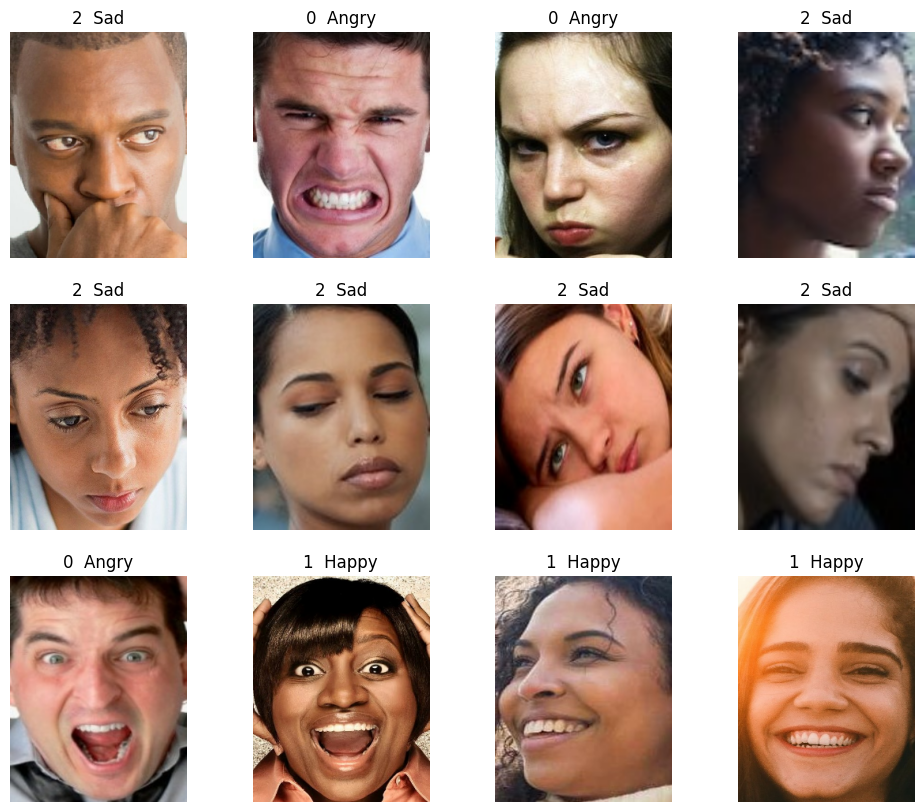

In [30]:
import matplotlib.pyplot as plt

def plot_images_from_dataset(dataset, class_names, num_images=12):
    """
    This function plots a specified number of images from a TensorFlow dataset.
    It also displays the class name as the title of each image.
    """
    plt.figure(figsize=(12, 10))
    # Take one batch from the dataset
    for images, labels in dataset.take(1):
        # Plot each image in the batch
        for i in range(num_images):
            plt.subplot(3, 4, i + 1)
            plt.imshow(images[i].numpy().astype('uint8'))
            plt.title(f'{labels[i]}  {class_names[labels[i]]}')
            plt.axis('off')
    # Show the plot
    plt.show()

class_names = get_class_names(DIRECTORY_NAME)
# Call the function with the training dataset and class names
plot_images_from_dataset(train_ds, class_names)

### Pembuatan Model
Arsitektur model dibuat sesuai aplikasi klasifikasi ekspresi wajah.

In [31]:
from tensorflow import keras
from keras.layers import Input, Rescaling, Flatten, BatchNormalization, Dense, Dropout
from keras.layers import Conv2D, Activation, MaxPooling2D, GlobalAveragePooling2D

def create_model(image_size = (224,224), class_number = 10):
    """
    This function creates a custom model.
    """
    # Define the image shape
    image_shape = image_size + (3,)
    # Define the model
    inputs = Input(shape=image_shape)
    x = Rescaling(1./255.)(inputs)
    x = Conv2D(32, 3, strides=2, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(3, strides=2)(x)
    x = Conv2D(32, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = GlobalAveragePooling2D()(x)
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(class_number, activation="softmax")(x)
    outputs = x
    # Create the model
    model = keras.Model(inputs, outputs)
    # Print the model's summary
    model.summary()
    print(f'Model created')
    return model

class_number = get_class_number(DIRECTORY_NAME)
# Call the function with the image size and the number of classes
model = create_model(image_size=IMAGE_SIZE,class_number=class_number)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 288, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 288, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 144, 112, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 144, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 144, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 71, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 71, 55, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 71, 55, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 71, 55, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,835 (112.64 KB)

 Trainable params: 28,707 (112.14 KB)

 Non-trainable params: 128 (512.00 B)

Model created


### Pelatihan Model
Atur jumlah epochs untuk mendapatkan akurasi model semaksimal mungkin. Pelatihan model dapat diulang jika akurasi belum memenuhi kriteria yang diinginkan.

In [32]:
import time
import datetime

def train_model(model, train_ds, val_ds, epochs=1000):
    """
    This function trains the model with the given training and validation datasets.
    """
    # Define the learning rate reduction callback
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.1, patience=50, min_lr=1e-6)
    # Define the early stopping callback
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='accuracy', patience=75, restore_best_weights=True)
    # Define the optimizer
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-3)
    # Compile the model
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    # Record the start time
    starttime = time.time()
    # Train the model
    model_history = model.fit(train_ds, epochs=epochs,
        validation_data=val_ds, callbacks=[reduce_lr, early_stopping])
    # Calculate and print the training time
    stoptime =  time.time() - starttime
    trainingtime = datetime.timedelta(seconds=stoptime)
    print(f'\nTraining time : {trainingtime}')
    print(f'End of training')
    # Return the model history
    return model_history

# Call the function with the model and the datasets
model_history = train_model(model, train_ds, val_ds)

Epoch 1/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 604ms/step - accuracy: 0.2609 - loss: 1.1150 - val_accuracy: 0.1739 - val_loss: 1.1059 - learning_rate: 0.0010
Epoch 2/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5435 - loss: 1.0297 - val_accuracy: 0.3043 - val_loss: 1.1043 - learning_rate: 0.0010
Epoch 3/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4674 - loss: 0.9704 - val_accuracy: 0.3043 - val_loss: 1.1152 - learning_rate: 0.0010
Epoch 4/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4891 - loss: 0.9517 - val_accuracy: 0.1739 - val_loss: 1.1204 - learning_rate: 0.0010
Epoch 5/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6413 - loss: 0.8998 - val_accuracy: 0.2174 - val_loss: 1.1100 - learning_rate: 0.0010
Epoch 6/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5543 - loss: 0.9064 - val_accuracy: 0.3478 - val_loss: 1.0764 - learning_rate: 0.0010
Epoch 7/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5435 - loss: 0.8999 - val_ac

### Evaluasi Performansi (Unjuk Kerja)
#### Training

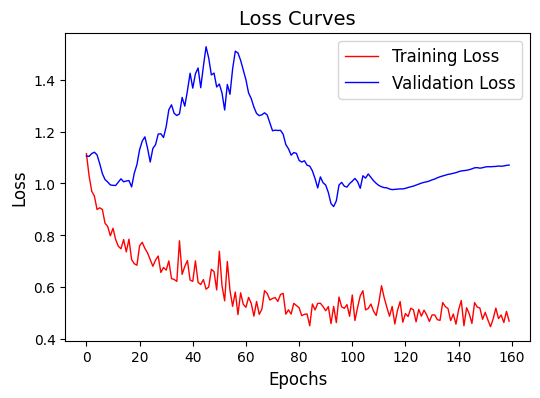

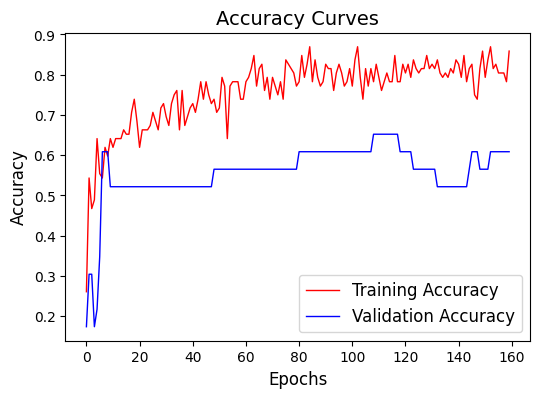

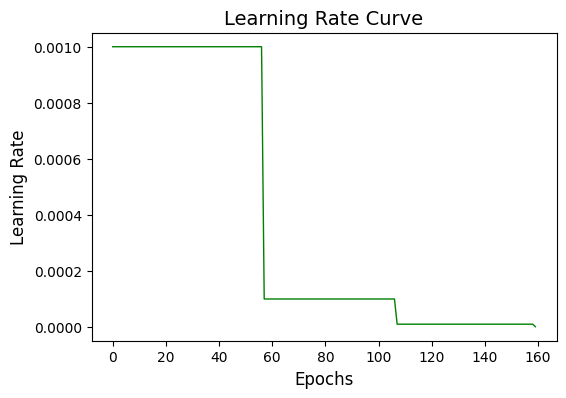

In [33]:
import matplotlib.pyplot as plt

def plot_model_history(model_history):
    """
    This function plots the loss, accuracy, and learning rate curves of the model training history.
    """
    # Create a figure for the loss curves
    plt.figure(figsize=[6, 4])
    plt.plot(model_history.history['loss'], 'r', linewidth=1.0)
    plt.plot(model_history.history['val_loss'], 'b', linewidth=1.0)
    plt.legend(['Training Loss', 'Validation Loss'], fontsize=12)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Loss Curves', fontsize=14)
    plt.show()
    # Create a figure for the accuracy curves
    plt.figure(figsize=[6, 4])
    plt.plot(model_history.history['accuracy'], 'r', linewidth=1.0)
    plt.plot(model_history.history['val_accuracy'], 'b', linewidth=1.0)
    plt.legend(['Training Accuracy', 'Validation Accuracy'], fontsize=12)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('Accuracy Curves', fontsize=14)
    plt.show()
    # Create a figure for the learning rate curve
    plt.figure(figsize=[6, 4])
    if (tf.__version__ == '2.9.3'):plt.plot(model_history.history['lr'], 'g', linewidth=1.0)
    else: plt.plot(model_history.history['learning_rate'], 'g', linewidth=1.0)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Learning Rate', fontsize=12)
    plt.title('Learning Rate Curve', fontsize=14)
    plt.show()

# Call the function with the model history
plot_model_history(model_history)

#### Confusion Matrix, Precision, Recall, F1 Score

Evaluate model using training data

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step


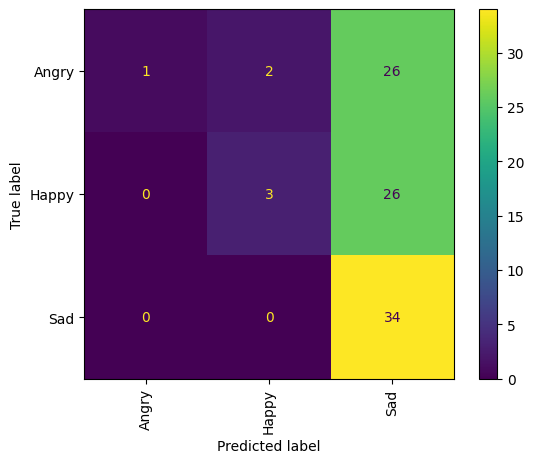

              precision    recall  f1-score   support

       Angry       1.00      0.03      0.07        29
       Happy       0.60      0.10      0.18        29
         Sad       0.40      1.00      0.57        34

    accuracy                           0.41        92
   macro avg       0.67      0.38      0.27        92
weighted avg       0.65      0.41      0.29        92

Evaluate model using validation data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step


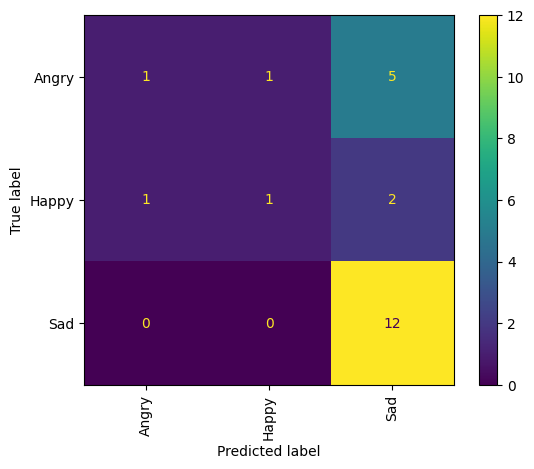

              precision    recall  f1-score   support

       Angry       0.50      0.14      0.22         7
       Happy       0.50      0.25      0.33         4
         Sad       0.63      1.00      0.77        12

    accuracy                           0.61        23
   macro avg       0.54      0.46      0.44        23
weighted avg       0.57      0.61      0.53        23



In [34]:
from sklearn import metrics

def evaluate_model(model, val_ds, class_names):
    """
    This function evaluates a given model on a validation dataset and prints the confusion matrix and classification report.
    """
    # Initialize empty lists for ground truth labels and predicted labels
    ground_truth = []
    pred_result = []
    # Iterate over the validation dataset
    for images, labels in val_ds:
        # Append the true labels to the ground truth list
        ground_truth.extend(labels.numpy())
        # Predict the labels for the current batch of images
        pred = model.predict(images)
        # Append the predicted labels to the prediction result list
        pred_result.extend(tf.argmax(pred, axis=1))
    # Compute the confusion matrix
    cm_test = metrics.confusion_matrix(ground_truth, pred_result)
    # Create a display for the confusion matrix
    cm_test_display = metrics.ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
    # Plot the confusion matrix
    cm_test_display.plot(xticks_rotation='vertical')
    plt.show()
    # Print the classification report
    print(metrics.classification_report(ground_truth, pred_result, target_names=class_names))

# Call the function with the model, train dataset, and class names
print(f'Evaluate model using training data\n')
evaluate_model(model, train_ds, class_names)
# Call the function with the model, validation dataset, and class names
print(f'Evaluate model using validation data\n')
evaluate_model(model, val_ds, class_names)

### Simpan Model

In [35]:
import os
import shutil

def save_model_to_drive(model, model_filename, run_on_colab, destination_dir):
    """
    This function saves a given model to Google Drive if running on Google Colab.
    """
    # Save the model locally
    model.save(model_filename)
    print(f'Model saved as {model_filename}')

    # If running on Google Colab, copy the model file to Google Drive
    if run_on_colab:
        # Mount Google Drive
        from google.colab import drive
        drive.mount('/content/drive')
        # Define the source path of the model file
        source_path = os.path.join(os.getcwd(), model_filename)
        # Define the destination path of the model file
        destination_path = os.path.join(destination_dir, model_filename)
        # Copy the model file to Google Drive
        shutil.copy(source_path, destination_path)
        print(f'{model_filename} copied successfully to {destination_dir}.')

model_filename = 'AHSModel_TF'+tf.__version__+'.keras'
# Call the function with the model, model filename, run_on_colab flag, and destination directory
save_model_to_drive(model, model_filename, RUN_COLAB, '/content/drive/MyDrive/Colab Notebooks')

Model saved as AHSModel_TF2.20.0.keras
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AHSModel_TF2.20.0.keras copied successfully to /content/drive/MyDrive/Colab Notebooks.


In [36]:
print(f'End of program... ')

End of program... 
